# PHYS 2550 — Homework 1: Linear regression from scratch

**Applied Machine Learning in Physics.** This notebook runs top-to-bottom (Runtime → Run all in Colab) using only **NumPy, pandas and matplotlib** — no scikit-learn, no PyTorch, no `np.polyfit`; every model is fitted by hand-written gradient descent or the normal equation.

## Part (a) — The data

We use the **Real estate valuation data set** from the UCI Machine Learning Repository (dataset **477**): 414 houses from the Sindian/Beitou districts of New Taipei City, Taiwan, collected by Yeh & Hsu (2018). UCI distributes the data as an `.xlsx` file; the conversion to CSV is a one-liner (pandas `read_excel` followed by `to_csv`).

The next cell works both in Colab and locally: if `real_estate.csv` is not already beside the notebook it downloads the zip from UCI, unpacks it, reads the Excel sheet and writes the CSV; otherwise it just loads the existing file.

In [1]:
import os
import io
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)
os.makedirs("figures", exist_ok=True)

CSV = "real_estate.csv"
UCI_URL = "https://archive.ics.uci.edu/static/public/477/real+estate+valuation+data+set.zip"

if not os.path.exists(CSV):
    # Colab / fresh machine: fetch the original XLSX from UCI and convert to CSV.
    with urllib.request.urlopen(UCI_URL) as resp:
        zf = zipfile.ZipFile(io.BytesIO(resp.read()))
    xlsx_name = [n for n in zf.namelist() if n.lower().endswith(".xlsx")][0]
    with zf.open(xlsx_name) as f:
        pd.read_excel(f, index_col=0).to_csv(CSV)
    print(f"downloaded from UCI and wrote {CSV}")
else:
    print(f"loading existing {CSV}")

df = pd.read_csv(CSV)

loading existing real_estate.csv


In [2]:
print("shape:", df.shape)
df.head()

shape: (414, 8)


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
cols = {
    "X1 transaction date": "transaction date (year + fraction of year, e.g. 2013.250 = March 2013)",
    "X2 house age": "house age (years)",
    "X3 distance to the nearest MRT station": "distance to nearest MRT station (metres)",
    "X4 number of convenience stores": "number of convenience stores within walking distance (count)",
    "X5 latitude": "latitude (degrees)",
    "X6 longitude": "longitude (degrees)",
    "Y house price of unit area": "house price per unit area (10,000 TWD / ping, 1 ping = 3.3 m^2)",
}
for c, desc in cols.items():
    print(f"{desc:75s}  range [{df[c].min():.3f}, {df[c].max():.3f}]  mean {df[c].mean():.3f}")
print("missing values:", int(df.isna().sum().sum()))

feat_cols = list(cols.keys())[:-1]
target = "Y house price of unit area"

transaction date (year + fraction of year, e.g. 2013.250 = March 2013)       range [2012.667, 2013.583]  mean 2013.149
house age (years)                                                            range [0.000, 43.800]  mean 17.713
distance to nearest MRT station (metres)                                     range [23.383, 6488.021]  mean 1083.886
number of convenience stores within walking distance (count)                 range [0.000, 10.000]  mean 4.094
latitude (degrees)                                                           range [24.932, 25.015]  mean 24.969
longitude (degrees)                                                          range [121.474, 121.566]  mean 121.533
house price per unit area (10,000 TWD / ping, 1 ping = 3.3 m^2)              range [7.600, 117.500]  mean 37.980
missing values: 0


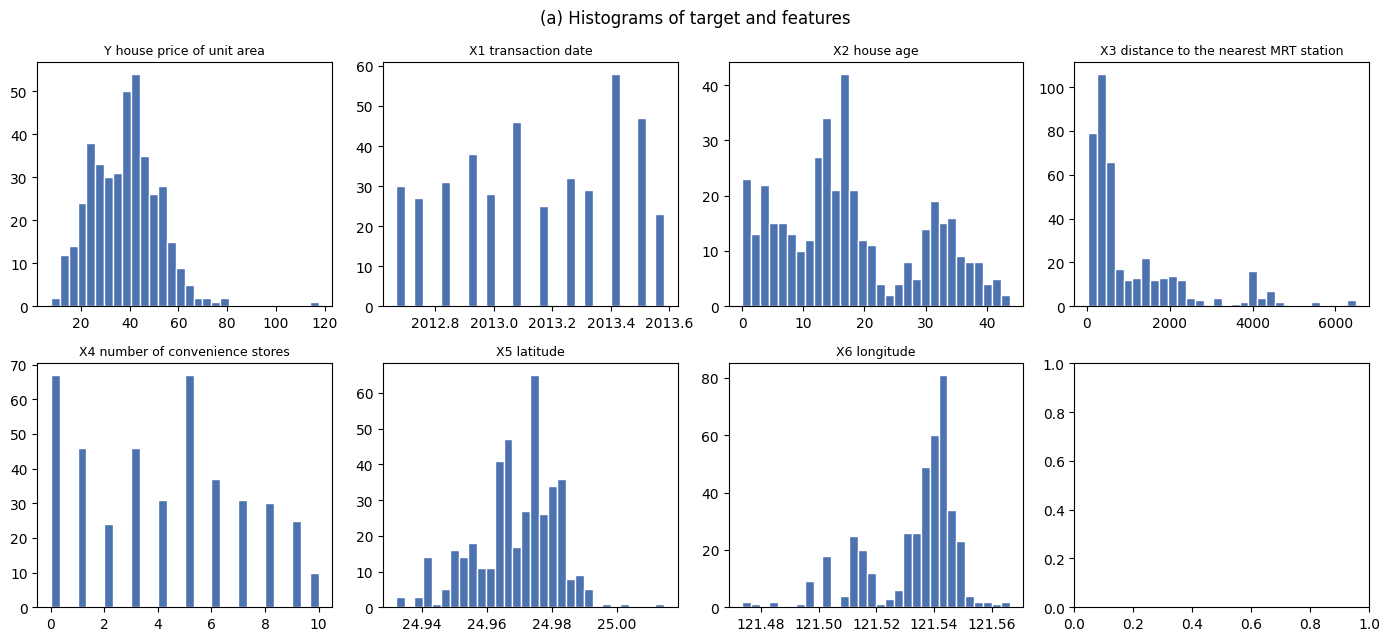

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6.5))
for ax, c in zip(axes.flat, [target] + feat_cols):
    ax.hist(df[c], bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(c, fontsize=9)
fig.suptitle("(a) Histograms of target and features")
fig.tight_layout()
fig.savefig("figures/fig_a_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

**Things worth noticing before fitting anything:**

- **No missing values** — all 414 rows are complete, so no imputation is needed.
- **X3 (MRT distance) is strongly right-skewed**: most houses sit within ~1 km of a station, but a tail of houses lies beyond 4000 m, out to 6488 m.
- **One house costs 117.5** (10k TWD/ping) — far above the bulk of the target distribution (mean ≈ 38). It will act as a high-leverage outlier for a least-squares fit.
- **Feature scales differ wildly**: X3 spans thousands of metres while X2 spans 0–44 years and X4 is a 0–10 count. Remember this for part (c) — it is exactly what breaks naive gradient descent.
- **X1 is a discrete monthly grid** (2012.667 … 2013.583), not a continuous timestamp.
- **X4 is integer counts**, and **X5/X6 (lat/long) form tight clusters** — the houses live in a few neighbourhoods rather than being spread uniformly.

## Part (b) — One feature: house age

Model (single feature $x$ = house age):

$$\hat{y} = w_0 + w_1\,x, \qquad L(w_0, w_1) = \frac{1}{N}\sum_{i=1}^{N}\left(w_0 + w_1 x_i - y_i\right)^2$$

**Gradients by hand.** Write $\hat{y}_i = w_0 + w_1 x_i$ and differentiate through the square (chain rule: $\frac{\partial}{\partial w}(\hat{y}_i - y_i)^2 = 2(\hat{y}_i - y_i)\,\frac{\partial \hat{y}_i}{\partial w}$):

$$\frac{\partial L}{\partial w_0} = \frac{1}{N}\sum_i 2(\hat{y}_i - y_i)\cdot \frac{\partial \hat{y}_i}{\partial w_0} = \frac{2}{N}\sum_i (\hat{y}_i - y_i)$$

$$\frac{\partial L}{\partial w_1} = \frac{1}{N}\sum_i 2(\hat{y}_i - y_i)\cdot \frac{\partial \hat{y}_i}{\partial w_1} = \frac{2}{N}\sum_i (\hat{y}_i - y_i)\,x_i$$

Gradient descent then updates $w_j \leftarrow w_j - \eta\,\partial L/\partial w_j$ each epoch.

In [5]:
y = df[target].to_numpy(float)
N = len(y)
x_b = df["X2 house age"].to_numpy(float)

def mse(pred, y):
    return np.mean((pred - y) ** 2)

def gd_single(x, y, lr, epochs):
    w0, w1 = 0.0, 0.0
    hist = []
    for ep in range(epochs):
        pred = w0 + w1 * x
        err = pred - y
        hist.append(mse(pred, y))
        w0 -= lr * 2.0 * err.mean()          # dL/dw0 = (2/N) sum (yhat - y)
        w1 -= lr * 2.0 * (err * x).mean()    # dL/dw1 = (2/N) sum (yhat - y) x
    return w0, w1, np.array(hist)

lr_b, ep_b = 0.001, 50000
w0_b, w1_b, hist_b = gd_single(x_b, y, lr_b, ep_b)
loss_b = hist_b[-1]
print(f"(b) lr={lr_b}, epochs={ep_b}  ->  w0={w0_b:.4f}, w1={w1_b:.4f}, MSE={loss_b:.4f}")
print("    (lr=0.01 diverges on this raw feature; lr=0.001 is stable)")

(b) lr=0.001, epochs=50000  ->  w0=42.4347, w1=-0.2515, MSE=176.5005
    (lr=0.01 diverges on this raw feature; lr=0.001 is stable)


**How the learning rate and epoch count were chosen.** With the raw (unnormalised) age feature, `lr=0.01` makes the loss *grow* — the gradient steps overshoot the minimum and diverge. The learning rate was halved repeatedly until the loss decreased monotonically, which first happens at `lr=0.001`. The epoch count (50 000) was then chosen by watching the loss curve: it is run long enough that the curve is visibly flat on a log scale, i.e. further epochs buy nothing.

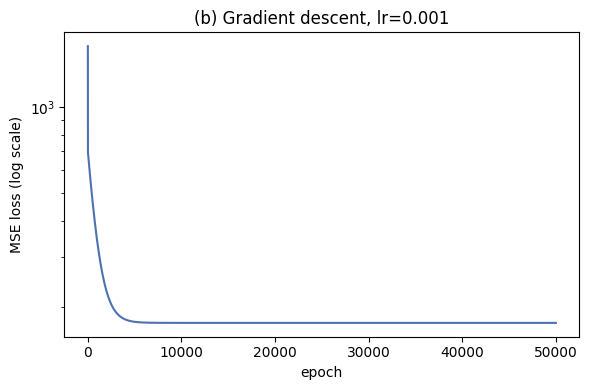

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hist_b, color="#4C72B0")
ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss (log scale)")
ax.set_title(f"(b) Gradient descent, lr={lr_b}")
fig.tight_layout()
fig.savefig("figures/fig_b_loss.png", dpi=150, bbox_inches="tight")
plt.show()

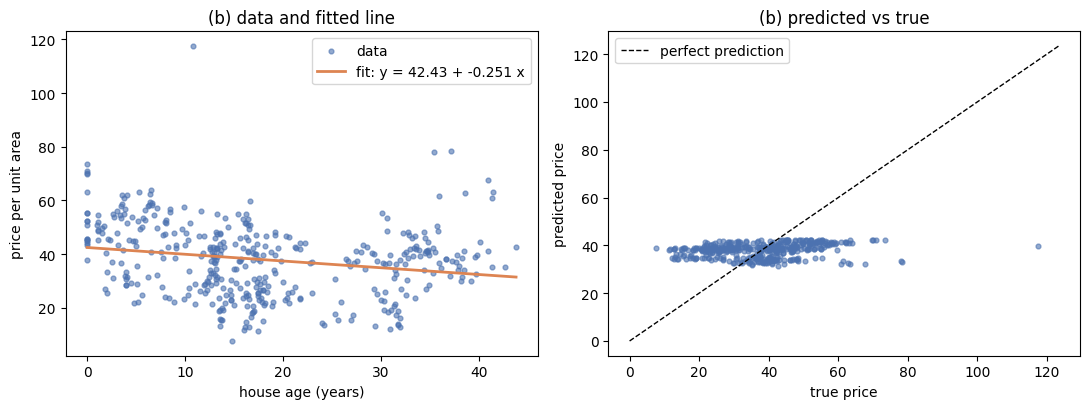

In [7]:
pred_b = w0_b + w1_b * x_b
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(x_b, y, s=12, alpha=0.6, color="#4C72B0", label="data")
xs = np.linspace(x_b.min(), x_b.max(), 100)
axes[0].plot(xs, w0_b + w1_b * xs, color="#DD8452", lw=2,
             label=f"fit: y = {w0_b:.2f} + {w1_b:.3f} x")
axes[0].set_xlabel("house age (years)"); axes[0].set_ylabel("price per unit area")
axes[0].legend(); axes[0].set_title("(b) data and fitted line")
axes[1].scatter(y, pred_b, s=12, alpha=0.6, color="#4C72B0")
lims = [0, max(y.max(), pred_b.max()) * 1.05]
axes[1].plot(lims, lims, "k--", lw=1, label="perfect prediction")
axes[1].set_xlabel("true price"); axes[1].set_ylabel("predicted price")
axes[1].legend(); axes[1].set_title("(b) predicted vs true")
fig.tight_layout()
fig.savefig("figures/fig_b_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation.** House age is a **weak predictor** on its own. The fitted slope is negative ($w_1 pprox -0.25$: each year of age knocks ≈ 0.25 off the price, on average), but the scatter around the line is enormous. The predicted-vs-true panel shows the predictions compressed into a narrow 30–45 band while the true prices span 8–117 — a single linear feature explains almost none of the variance, and the MSE of ≈ 176.5 is barely below the variance of the target itself.

## Part (c) — Three features, vectorised: raw vs normalised

Now use $d=3$ features (house age, MRT distance, convenience stores). Append a constant 1 to each feature vector, $\tilde{x} = (1, x_1, \dots, x_d)$, so the bias is just another weight:

$$\hat{y} = w^\top \tilde{x}, \qquad L(w) = \frac{1}{N}\lVert Xw - y \rVert^2, \qquad \nabla_w L = \frac{2}{N} X^\top (Xw - y)$$

where $X$ is the $N \times (d+1)$ design matrix. The update $w \leftarrow w - \eta\,\nabla_w L$ is fully vectorised and works for any number of features.

In [8]:
use = ["X2 house age", "X3 distance to the nearest MRT station",
       "X4 number of convenience stores"]
X_raw = df[use].to_numpy(float)                      # (N, 3)
mu, sd = X_raw.mean(0), X_raw.std(0)
X_norm = (X_raw - mu) / sd

def design(X):
    return np.column_stack([np.ones(len(X)), X])     # append constant 1

def gd_vec(X, y, lr, epochs):
    """Gradient descent; stops and returns the finite prefix if the loss
    blows up past 1e15 (divergence), so histories stay plottable."""
    Xd = design(X)
    w = np.zeros(Xd.shape[1])
    hist = []
    for ep in range(epochs):
        err = Xd @ w - y
        loss = np.mean(err ** 2)
        if not np.isfinite(loss) or loss > 1e15:     # diverged: stop early
            break
        hist.append(loss)
        w -= lr * 2.0 * (Xd.T @ err) / len(y)
    return w, np.array(hist)

lr_c, ep_c = 0.01, 5000
lr_div = 1e-6
w_raw_bad, hist_raw_bad = gd_vec(X_raw, y, lr_div, ep_c)    # unstable on raw -> diverges
w_raw_slow, hist_raw_slow = gd_vec(X_raw, y, 1e-7, ep_c)    # tiny lr -> crawls
w_norm, hist_norm = gd_vec(X_norm, y, lr_c, ep_c)           # normalised -> fine
loss_c = hist_norm[-1]
div_ep = len(hist_raw_bad)
print(f"(c) features: {use}")
print(f"    raw, lr={lr_div}: loss blew past 1e15 by epoch {div_ep} (diverges)")
print(f"    raw, lr=1e-7: final loss = {hist_raw_slow[-1]:.2f} after {ep_c} epochs (still far from optimum)")
print(f"    normalised, lr={lr_c}: w = {np.round(w_norm,4)}, MSE = {loss_c:.4f}")

(c) features: ['X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores']
    raw, lr=1e-06: loss blew past 1e15 by epoch 10 (diverges)
    raw, lr=1e-7: final loss = 996.36 after 5000 epochs (still far from optimum)
    normalised, lr=0.01: w = [37.9802 -2.8772 -6.7808  3.8171], MSE = 84.7607


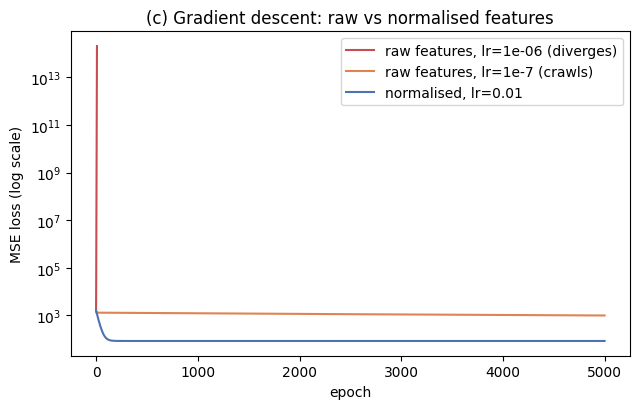

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(np.arange(div_ep), hist_raw_bad, color="#C44E52", lw=1.5,
        label=f"raw features, lr={lr_div:g} (diverges)")
ax.plot(hist_raw_slow, color="#DD8452", lw=1.5, label="raw features, lr=1e-7 (crawls)")
ax.plot(hist_norm, color="#4C72B0", lw=1.5, label=f"normalised, lr={lr_c}")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss (log scale)")
ax.set_title("(c) Gradient descent: raw vs normalised features")
ax.legend()
fig.tight_layout()
fig.savefig("figures/fig_c_loss.png", dpi=150, bbox_inches="tight")
plt.show()

**Why do the raw features fail?** The curvature of the MSE loss along weight direction $j$ is set by the scale of feature $j$ (the Hessian is $\frac{2}{N}X^\top X$, whose diagonal entries are the feature second moments). MRT distance spans 0–6500 m while house age spans 0–44 years, so the loss valley is roughly $(6500/44)^2 \sim 10^{4}$–$10^{5}$ times more curved along the distance weight than along the age weight. Gradient descent has a *single* learning rate for all directions: any $\eta$ large enough to move the age weight explodes along the distance direction (raw, $\eta=10^{-6}$: the loss passes $10^{15}$ within 10 epochs), and any $\eta$ small enough to be safe for distance barely moves at all (raw, $\eta=10^{-7}$: MSE is still ≈ 996 after 5000 epochs, vs ≈ 85 at the optimum). Normalising each feature (subtract the mean, divide by the standard deviation) equalises the curvatures, and suddenly $\eta = 0.01$ converges smoothly.

In [10]:
pred_c = design(X_norm) @ w_norm
print(f"(c) final weights (normalised features): w = {np.round(w_norm, 4)}")
print(f"(c) MSE = {loss_c:.4f}")
print(f"(b) MSE = {loss_b:.4f}")
print(f"improvement: {loss_b / loss_c:.2f}x lower MSE than the age-only model")

(c) final weights (normalised features): w = [37.9802 -2.8772 -6.7808  3.8171]
(c) MSE = 84.7607
(b) MSE = 176.5005
improvement: 2.08x lower MSE than the age-only model


## Part (d) — Model comparison and feature relevance

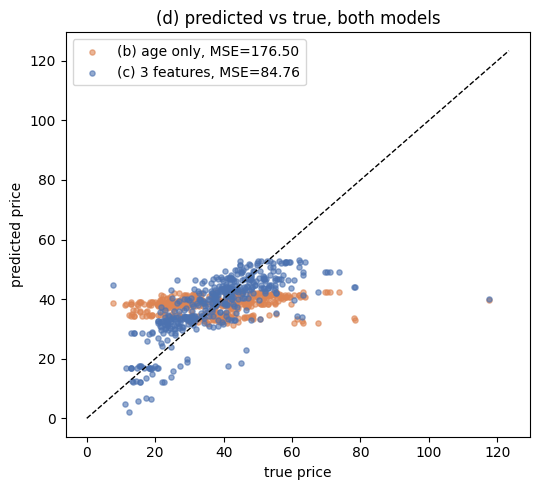

In [11]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y, pred_b, s=14, alpha=0.6, color="#DD8452", label=f"(b) age only, MSE={loss_b:.2f}")
ax.scatter(y, pred_c, s=14, alpha=0.6, color="#4C72B0", label=f"(c) 3 features, MSE={loss_c:.2f}")
lims = [0, max(y.max(), pred_c.max()) * 1.05]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("true price"); ax.set_ylabel("predicted price")
ax.set_title("(d) predicted vs true, both models")
ax.legend()
fig.tight_layout()
fig.savefig("figures/fig_d_pred_vs_true.png", dpi=150, bbox_inches="tight")
plt.show()

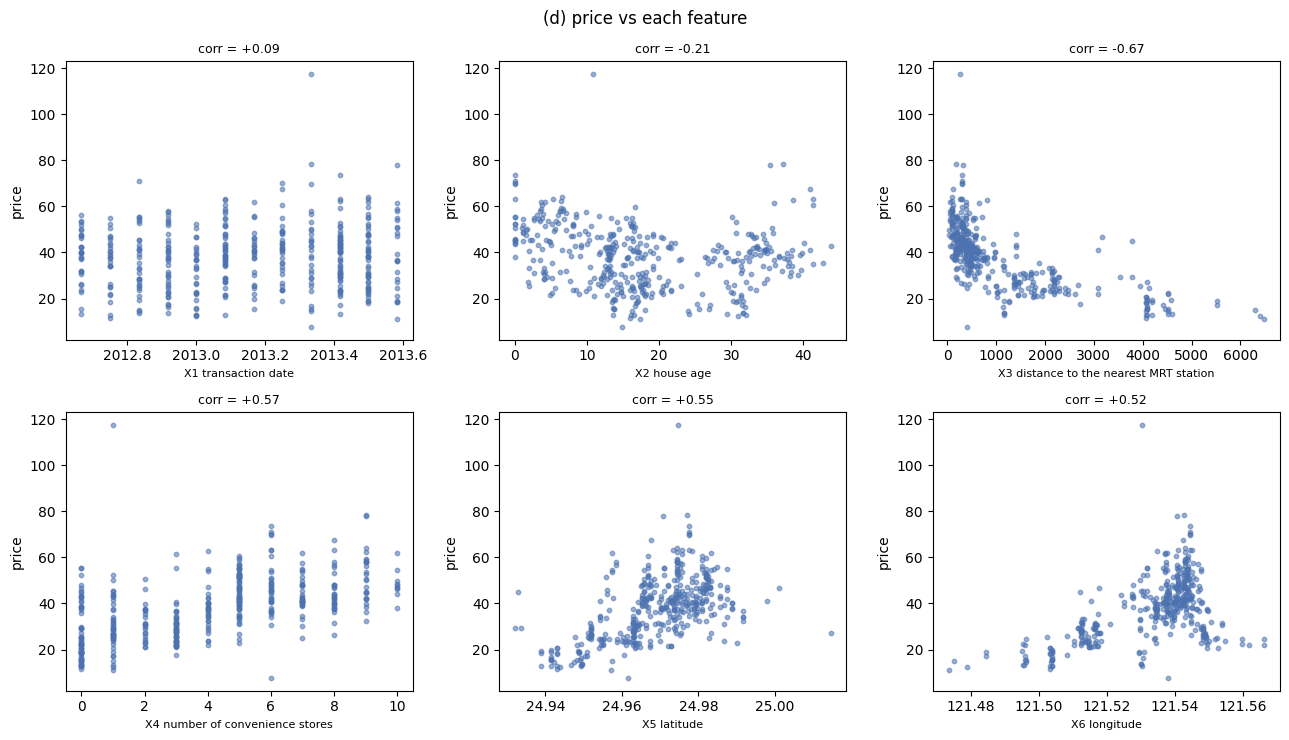

  corr(price, X3 distance to the nearest MRT station       ) = -0.67
  corr(price, X4 number of convenience stores              ) = +0.57
  corr(price, X5 latitude                                  ) = +0.55
  corr(price, X6 longitude                                 ) = +0.52
  corr(price, X2 house age                                 ) = -0.21
  corr(price, X1 transaction date                          ) = +0.09


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for ax, c in zip(axes.flat, feat_cols):
    ax.scatter(df[c], y, s=10, alpha=0.55, color="#4C72B0")
    r = np.corrcoef(df[c], y)[0, 1]
    ax.set_xlabel(c, fontsize=8); ax.set_ylabel("price")
    ax.set_title(f"corr = {r:+.2f}", fontsize=9)
fig.suptitle("(d) price vs each feature")
fig.tight_layout()
fig.savefig("figures/fig_d_price_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()

corr = {c: float(np.corrcoef(df[c], y)[0, 1]) for c in feat_cols}
for c, r in sorted(corr.items(), key=lambda kv: -abs(kv[1])):
    print(f"  corr(price, {c:45s}) = {r:+.2f}")

**Discussion.**

*Which features carry information?* The correlation ranking is unambiguous: **MRT distance** ($r pprox -0.67$) is the strongest single signal — closer to the metro means more expensive — followed by **convenience stores** ($r pprox +0.57$) and the **location coordinates** (latitude $+0.55$, longitude $+0.52$), which together encode neighbourhood. **House age** is weak ($r pprox -0.21$), consistent with the poor single-feature fit in part (b), and **transaction date** carries essentially nothing ($r pprox +0.09$) — prices were flat over this one-year window. This matches the fitted weights in (c): the MRT-distance weight has the largest magnitude, then stores, then age.

*What limited the fit?* Even the 3-feature model leaves an MSE of ≈ 84.8. Three culprits: (1) **outliers** — the 117.5 house and the far-MRT houses (>4000 m) are high-leverage points that a squared loss bends towards; (2) **feature scale** — as part (c) showed, the raw scales make optimisation ill-conditioned, and normalisation was mandatory rather than cosmetic; (3) **model class** — a linear model cannot capture saturation (price vs MRT distance flattens beyond ~1 km) or interactions between features, and the predicted-vs-true plot shows the model systematically under-predicting the most expensive houses.

*What would a second version change?* Add **latitude/longitude** to the feature set (they correlate with price as strongly as stores); **log-transform X3** to compress its right tail and linearise the saturation; **handle outliers** (clip or use a robust loss such as Huber); and do a **train/test split** so the reported MSE measures generalisation rather than in-sample fit.

## Bonus — Normal equation

Least squares has a closed-form solution. Setting $\nabla_w L = \frac{2}{N}X^\top(Xw - y) = 0$ gives the **normal equation**:

$$w^* = (X^\top X)^{-1} X^\top y$$

In code we solve the linear system $X^\top X\, w = X^\top y$ with `np.linalg.solve` rather than explicitly inverting $X^\top X$ (numerically stabler and faster).

In [13]:
Xd = design(X_norm)
w_star = np.linalg.solve(Xd.T @ Xd, Xd.T @ y)         # (X^T X)^-1 X^T y, via solve not inv
loss_star = mse(Xd @ w_star, y)
print(f"bonus: normal equation w* = {np.round(w_star,6)}, MSE = {loss_star:.6f}")
print(f"       GD (c) reached w = {np.round(w_norm,6)}, MSE = {loss_c:.6f}")
print(f"       |w_GD - w*|_max = {np.max(np.abs(w_norm - w_star)):.2e}")

# how many epochs for GD to get within 1e-4 (relative) of the closed-form loss?
tol = 1e-4
need = next(i for i, l in enumerate(hist_norm) if (l - loss_star) / loss_star < tol)
print(f"       GD within 0.01% of closed-form loss after {need} epochs")

# closed form for the single-feature model, for reference
Xd_b = design(x_b.reshape(-1, 1))
w_star_b = np.linalg.solve(Xd_b.T @ Xd_b, Xd_b.T @ y)
loss_b_star = mse(Xd_b @ w_star_b, y)
print(f"       (b) closed form: w0={w_star_b[0]:.4f}, w1={w_star_b[1]:.4f}, "
      f"MSE={loss_b_star:.4f} (GD got {w0_b:.4f}, {w1_b:.4f}, MSE={loss_b:.4f})")

bonus: normal equation w* = [37.980193 -2.877175 -6.780847  3.817079], MSE = 84.760706
       GD (c) reached w = [37.980193 -2.877175 -6.780847  3.817079], MSE = 84.760706
       |w_GD - w*|_max = 1.71e-13
       GD within 0.01% of closed-form loss after 336 epochs
       (b) closed form: w0=42.4347, w1=-0.2515, MSE=176.5005 (GD got 42.4347, -0.2515, MSE=176.5005)


**How close is "close enough"?** Define convergence as a relative loss gap $(L_{GD} - L^*)/L^* < 10^{-4}$ (within 0.01% of the closed-form optimum). Normalised gradient descent crosses that threshold at **epoch 336** — the remaining ~4600 epochs only polish the weights (eventually matching $w^*$ to $|\Delta w|_{max} pprox 1.7	imes10^{-13}$, i.e. floating-point agreement). The same check on the single-feature model confirms the hand-derived gradients were correct: GD and the normal equation agree to 11 decimal places there too.